## LECTURE 02

In [58]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

from sklearn.neighbors import KernelDensity

from astropy.visualization import hist
from sklearn.mixture import GaussianMixture

In [59]:
random_state = np.random.RandomState(seed=0)
N = 2000 # number of data points
mu_gamma_f = [(5, 1.0, 0.1),
              (7, 0.5, 0.5),
              (9, 0.1, 0.1),
              (12, 0.5, 0.2),
              (14, 1.0, 0.1)]
hx = lambda x: sum([f * stats.cauchy(mu, gamma).pdf(x)
                          for (mu, gamma, f) in mu_gamma_f])
x = np.concatenate([stats.cauchy(mu, gamma).rvs(int(f * N), random_state=random_state)
                    for (mu, gamma, f) in mu_gamma_f])
random_state.shuffle(x)
x = x[x > -10]
x = x[x < 30]

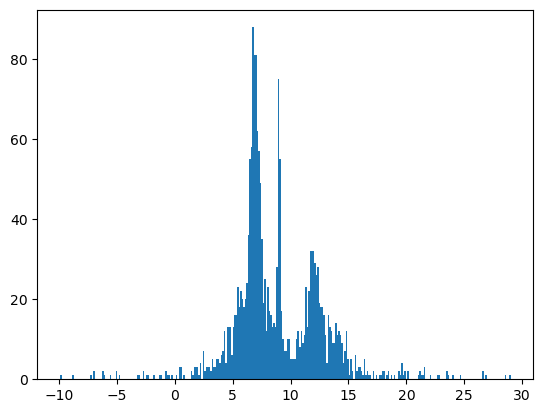

In [60]:
#Let's do the easiest thing ever.
plt.hist(x,bins=300);

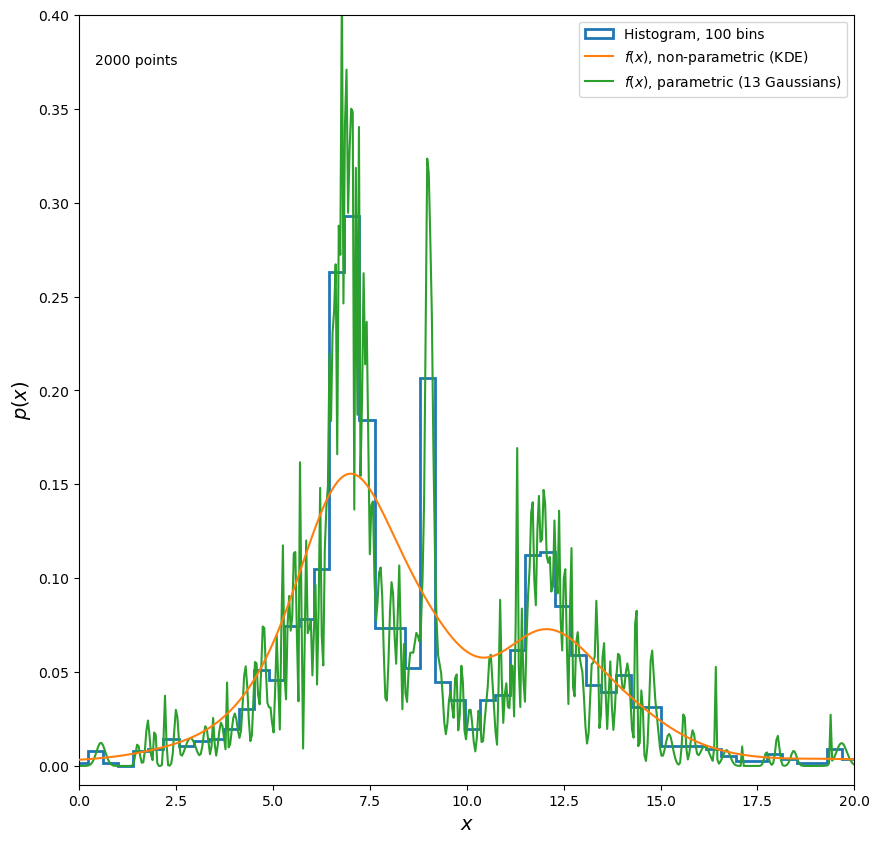

In [61]:
#------------------------------------------------------------
# plot the results
fig,ax = plt.subplots(figsize=(10, 10))
xgrid = np.linspace(-10, 30, 1000)

# True distribution: you typically don't have it! Only have the samples!
if False:
    ax.plot(xgrid, hx(xgrid), ':', color='black', zorder=3,
            label="$h(x)$, Generating Distribution")

# A simple histogram
# But try changing the number of bins!
if True:
    ax.hist(x,density=True,color='C0',bins=100,histtype='step',lw=2, label='Histogram, 100 bins')

# Something more sophisticated: Kernel Density Estimation
# But try changing the bandwith! 
if True:
    kde = KernelDensity(bandwidth=1, kernel='gaussian')
    kde.fit(x[:, None])
    dens_kde = np.exp(kde.score_samples(xgrid[:, None]))
    ax.plot(xgrid, dens_kde, '-', color='C1', zorder=3,
            label="$f(x)$, non-parametric (KDE)")

# Use Gaussian Mixtures with a pre-defined number of clusters (13)
if True:
    gmm = GaussianMixture(n_components=130).fit(x.reshape(-1, 1))
    logprob = gmm.score_samples(xgrid.reshape(-1, 1))
    fx = lambda j : np.exp(gmm.score_samples(j.reshape(-1, 1)))
    ax.plot(xgrid, fx(np.array(xgrid)), '-', color='C2',
            label="$f(x)$, parametric (13 Gaussians)")

# Plot cosmetics
ax.text(0.02, 0.95, "%i points" % N, ha='left', va='top',
            transform=ax.transAxes)

ax.set_ylabel('$p(x)$',fontsize=14)
ax.legend(loc='upper right')

ax.set_xlabel('$x$',fontsize=14)
ax.set_xlim(0, 20)
ax.set_ylim(-0.01, 0.4001)

plt.show()

### Kernel Density Estimation vs Gaussian Mixture Model
KDE: non parametric, kernel=gaussain, associa a ogni punto una gaussiana, ne costruisce la sovrapposizione \
     bandwidth gestisce l'ampiezza delle gaussiane, troppo larga poor fit, troppo stretta overfitting \
GMM: parametric, guess the number of gaussian, algorithm finds their centers and width, ne costruisce la sovrapposizione \
     small n of gauss poor fit, huge n of gauss overfit

Overfitting means to let the algorithm learn the noise given its too high flexibility

In [62]:
# For instance in a single point:
print(hx(6))             # h(x), the true distribution
print(fx(np.array([6]))) # f(x) for a parametric model
print(np.exp(kde.score_samples(np.atleast_2d(6)))) # f(x) for non-parametric model

0.08129856041320353
[0.05892329]
[0.12182447]


## MONTY HALL PROBLEM

Simulate the problem by recording if the different strategies wins or not with boolean variables
Define doors, choice of the partecipate and obliged choice of the host. These are chosen randomly. 
In this way every time the different possible choice of the player (conservative,switch,random) lead to a different winner
Record wins verifying if each player has the goat in the door with a boolean variable.

In [63]:
import random

def play_monty_hall():
    #simulates all strategies
    
    doors = ['goat', 'goat', 'car']
    random.shuffle(doors)

    initial_choice = random.randint(0, 2)
    
    possible_host_doors = [i for i in range(3) if i != initial_choice and doors[i] == 'goat']
    host_opened = random.choice(possible_host_doors)
    
    remaining_door = [i for i in range(3) if i != initial_choice and i != host_opened][0] #estrae indice 

    # use bool var to check wins
    conservative_win = (doors[initial_choice] == 'car') #expect 0.33
    switcher_win = (doors[remaining_door] == 'car')     #expect 0.66
    
    # newcomer sees only 2 doors, expect 0.50
    newcomer_choice = random.choice([initial_choice, remaining_door])
    newcomer_win = (doors[newcomer_choice] == 'car')
    
    return conservative_win, switcher_win, newcomer_win
    
def run_simulation(num_trials=1000):
    conservative_wins = 0
    switcher_wins = 0
    newcomer_wins = 0
    
    for i in range(num_trials):
        conservative_win, switcher_win, newcomer_win = play_monty_hall()
        #sum directly bool result (0,1) to update victory
        conservative_wins += conservative_win
        switcher_wins += switcher_win
        newcomer_wins += newcomer_win
    
        #print(conservative_wins, switcher_wins, newcomer_wins)

    cons_win_perc = conservative_wins / num_trials * 100
    switch_win_perc = switcher_wins / num_trials * 100
    newcom_win_perc = newcomer_wins / num_trials * 100

    print(f"Conservative strategy win percentage: {cons_win_perc:.2f}%", f"Switcher strategy win percentage: {switch_win_perc:.2f}%", f"Newcomer strategy win percentage: {newcom_win_perc:.2f}%")

run_simulation()




Conservative strategy win percentage: 36.40% Switcher strategy win percentage: 63.60% Newcomer strategy win percentage: 50.60%


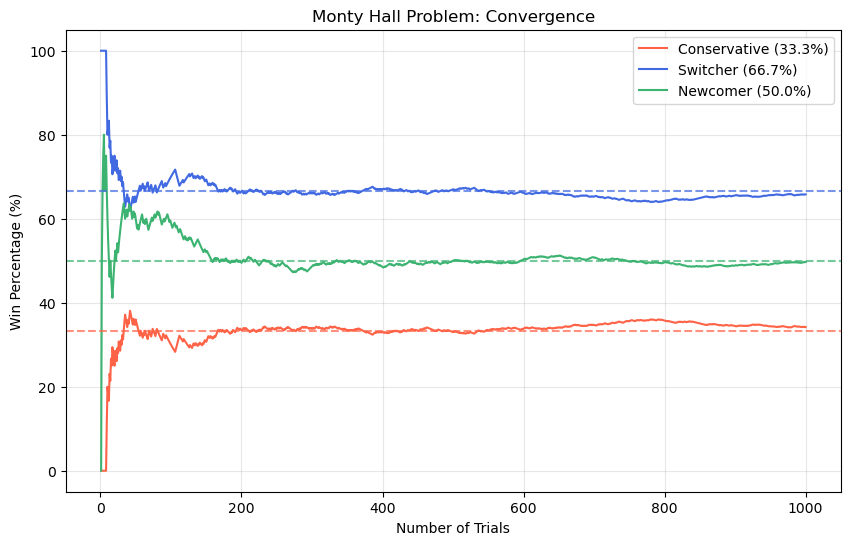

In [64]:
import matplotlib.pyplot as plt
import numpy as np

def plot_convergence(num_trials=1000):
    cons_history = []
    switch_history = []
    newcom_history = []
    
    cons_wins = 0
    switch_wins = 0
    newcom_wins = 0
    
    for i in range(1, num_trials + 1):
        c_win, s_win, n_win = play_monty_hall()
        cons_wins += c_win
        switch_wins += s_win
        newcom_wins += n_win
        
        cons_history.append(cons_wins / i * 100)
        switch_history.append(switch_wins / i * 100)
        newcom_history.append(newcom_wins / i * 100)
        
    plt.figure(figsize=(10, 6))
    trials = np.arange(1, num_trials + 1)
    plt.plot(trials, cons_history, label='Conservative (33.3%)', color='tomato')
    plt.plot(trials, switch_history, label='Switcher (66.7%)', color='royalblue')
    plt.plot(trials, newcom_history, label='Newcomer (50.0%)', color='mediumseagreen')
    
    plt.axhline(33.33, color='tomato', linestyle='--', alpha=0.7)
    plt.axhline(66.67, color='royalblue', linestyle='--', alpha=0.7)
    plt.axhline(50.00, color='mediumseagreen', linestyle='--', alpha=0.7)
    
    plt.xlabel('Number of Trials')
    plt.ylabel('Win Percentage (%)')
    plt.title('Monty Hall Problem: Convergence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_convergence()


### N doors generalization

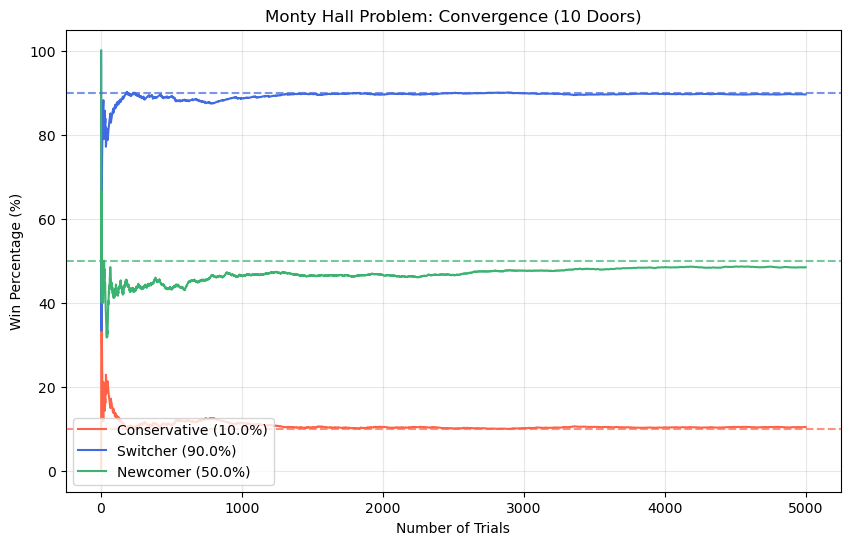

In [65]:
import random
import numpy as np
import matplotlib.pyplot as plt

def play_monty_hall_n_doors(num_doors):
    #simulates all strategies with N doors
    
    doors = ['goat'] * (num_doors - 1) + ['car']
    random.shuffle(doors)

    initial_choice = random.randint(0, num_doors - 1)
    
    available_goats = [i for i in range(num_doors) if i != initial_choice and doors[i] == 'goat']
    
    #host opens all N-2 doors with .sample 
    host_opened = random.sample(available_goats, num_doors - 2)
    
    remaining_door = [i for i in range(num_doors) if i != initial_choice and i not in host_opened][0]

    conservative_win = (doors[initial_choice] == 'car') #expect 1/N chance to win
    switcher_win = (doors[remaining_door] == 'car')     #expect 1/N * (N-1) chance to win

    #again newcomer only sees two doors, expect 50%
    newcomer_choice = random.choice([initial_choice, remaining_door])
    newcomer_win = (doors[newcomer_choice] == 'car')
    
    return conservative_win, switcher_win, newcomer_win
    
def plot_convergence_n_doors(num_doors=10, num_trials=5000):
    """Simula e traccia il grafico di convergenza per N porte."""
    cons_history = []
    switch_history = []
    newcom_history = []
    
    cons_wins = 0
    switch_wins = 0
    newcom_wins = 0
    
    for i in range(1, num_trials + 1):
        c_win, s_win, n_win = play_monty_hall_n_doors(num_doors)
        cons_wins += c_win
        switch_wins += s_win
        newcom_wins += n_win
        
        cons_history.append(cons_wins / i * 100)
        switch_history.append(switch_wins / i * 100)
        newcom_history.append(newcom_wins / i * 100)
        
    # Calcolo dei limiti teorici esatti in base a N
    cons_theo = (1 / num_doors) * 100
    switch_theo = ((num_doors - 1) / num_doors) * 100
    newcom_theo = 50.0 # È sempre 50%, perché alla fine rimangono sempre 2 porte!

    plt.figure(figsize=(10, 6))
    trials = np.arange(1, num_trials + 1)
    
    plt.plot(trials, cons_history, label=f'Conservative ({cons_theo:.1f}%)', color='tomato')
    plt.plot(trials, switch_history, label=f'Switcher ({switch_theo:.1f}%)', color='royalblue')
    plt.plot(trials, newcom_history, label=f'Newcomer ({newcom_theo:.1f}%)', color='mediumseagreen')
    
    plt.axhline(cons_theo, color='tomato', linestyle='--', alpha=0.7)
    plt.axhline(switch_theo, color='royalblue', linestyle='--', alpha=0.7)
    plt.axhline(newcom_theo, color='mediumseagreen', linestyle='--', alpha=0.7)
    
    plt.xlabel('Number of Trials')
    plt.ylabel('Win Percentage (%)')
    plt.title(f'Monty Hall Problem: Convergence ({num_doors} Doors)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Esempio: lanciamo la simulazione con 10 porte
plot_convergence_n_doors(num_doors=10, num_trials=5000)